**Time series analysis of layoff frequency across January to March 2026**

In [2]:
# Importing Libraries
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter


# Loading and Cleaning data
df = pd.read_csv(r"C:\Users\arjun\Desktop\Tech Layoff Analysis\tech_layoffs_2026_tracker.csv")
df.drop_duplicates(inplace=True,subset=['company','jobs_cut','pct_workforce_cut','sector','country','hq_city','ai_cited','company_revenue_2025_bn','pre_layoff_headcount','stock_change_day_pct','simultaneous_ai_investment_bn'])
df['layoff_date'] = pd.to_datetime(df['layoff_date'])

**Time series analysis of layoff frequency across January to March 2026**

In [3]:
df['layoff_month'] = df['layoff_date'].dt.strftime('%b')
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of,layoff_month
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026",Jan
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026",Feb
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026",Jan
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026",Mar
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026",Feb


In [4]:
df_month = df.groupby('layoff_month')[['jobs_cut']].sum().copy()
df_month

,jobs_cut
layoff_month,
Feb,46588
Jan,32800
Mar,20758


In [5]:
df_month.reset_index(inplace=True)
df_month['month_no'] = pd.to_datetime(df_month['layoff_month'],format='%b').dt.month
df_month

,layoff_month,jobs_cut,month_no
0,Feb,46588,2
1,Jan,32800,1
2,Mar,20758,3


In [6]:
df_month.sort_values('month_no',inplace=True)
df_month.drop('month_no',axis=1,inplace=True)
df_month.set_index('layoff_month',inplace=True)
df_month

,jobs_cut
layoff_month,
Jan,32800
Feb,46588
Mar,20758


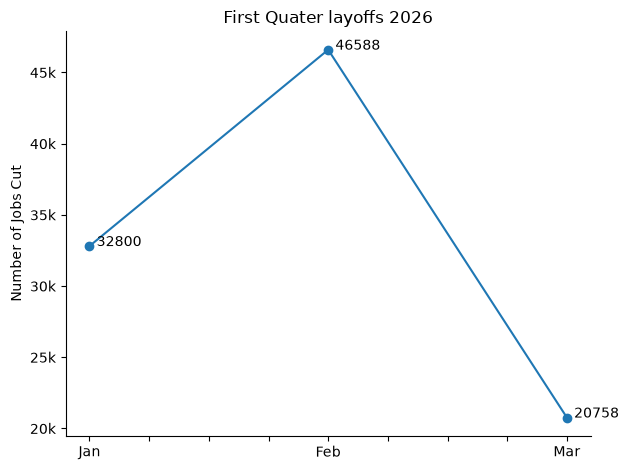

In [7]:
fig, ax = plt.subplots()

df_month.plot(kind='line',marker='o',legend=False, ax=ax)
plt.title('First Quater layoffs 2026')
plt.xlabel('')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos : f'{x/1000:.0f}k'))
plt.ylabel('Number of Jobs Cut')

for i in range(0,3):
    plt.text(i+.03,df_month['jobs_cut'].iloc[i],df_month['jobs_cut'].iloc[i])
sns.despine()
fig.tight_layout()

**February saw a sharp spike in reported layoffs, largely driven by Oracle, while March returned to a much lower level.**

In [8]:
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of,layoff_month
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026",Jan
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026",Feb
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026",Jan
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026",Mar
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026",Feb


**Layoff in each Month for all 3 years**

In [30]:
df_months_years = df.groupby('layoff_month')[['jobs_cut','layoffs_2024','layoffs_2025']].sum()
df_months_years.reset_index(inplace=True)
df_months_years['month_no'] = pd.to_datetime(df_months_years['layoff_month'],format='%b').dt.month
df_months_years.sort_values('month_no',inplace=True)
df_months_years.drop('month_no',inplace=True,axis=1)
df_months_years.set_index('layoff_month')
df_months_years

,layoff_month,jobs_cut,layoffs_2024,layoffs_2025
1,Jan,32800,11750,28950
0,Feb,46588,11700,23200
2,Mar,20758,3000,2500


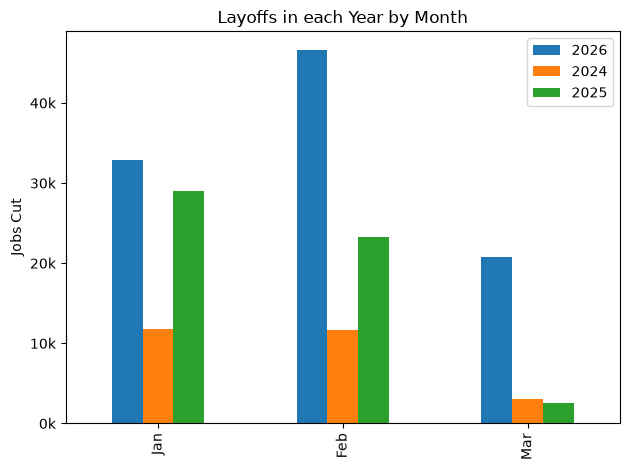

In [31]:
df_months_years = df_months_years.rename(columns={'jobs_cut': '2026', 'layoffs_2024':'2024', 'layoffs_2025':'2025'})
df_months_years.plot(kind='bar', x='layoff_month')
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos : f'{x/1000:.0f}k'))
plt.title('Layoffs in each Year by Month')
plt.ylabel('Jobs Cut')
plt.xlabel('')
plt.tight_layout()


**Q1 2026 shows a significantly higher level of reported layoffs compared with Q1 2024 and Q1 2025, with the gap widening sharply in February. However, the February spike is heavily influenced by Oracle’s large layoff event, while March still remains substantially above the previous two years.**

In [32]:
df

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of,layoff_month
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026",Jan
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026",Feb
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026",Jan
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026",Mar
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026",Feb
5,Salesforce,2026-01-10,1000,1.4,CRM/SaaS,USA,San Francisco,True,AI-driven efficiency and restructuring,37.9,...,1000,NetworkWorld / Bloomberg,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.39,"March 18, 2026",Jan
6,Autodesk,2026-01-25,1000,9.0,Design Software,USA,San Francisco,False,Post-Ansys acquisition restructuring,5.9,...,1200,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,9.09,"March 18, 2026",Jan
7,eBay,2026-01-28,800,5.0,E-Commerce,USA,San Jose,True,AI-forward strategy in customer ops,10.3,...,1000,NetworkWorld,January 2026,Q1 2026,North America,Medium (500-2K),Positive,7.27,"March 18, 2026",Jan
8,Pinterest,2026-02-10,675,4.0,Social Media,USA,San Francisco,True,AI-forward content and marketing strategy,3.6,...,200,NetworkWorld,February 2026,Q1 2026,North America,Medium (500-2K),Positive,18.24,"March 18, 2026",Feb
9,Ericsson,2026-01-15,1600,12.0,Telecommunications,Sweden,Stockholm,False,Declining 5G demand and cost reduction,24.3,...,5000,InformationWeek / FierceNetwork,January 2026,Q1 2026,Europe,Medium (500-2K),Positive,1.52,"March 18, 2026",Jan


**Compare AI-cited vs non-AI-cited layoffs by size, sector and stock reaction**

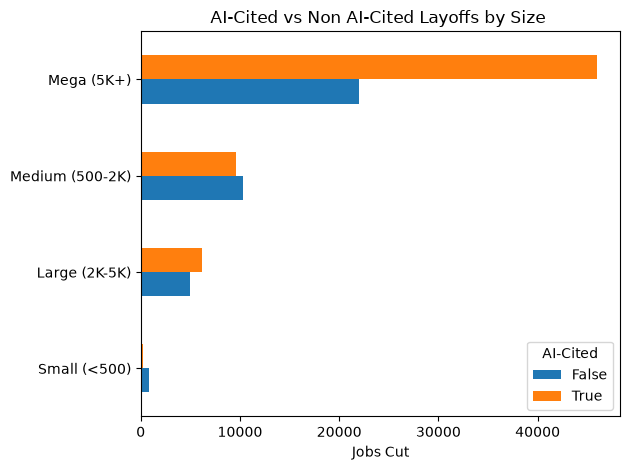

In [45]:
df_pivoted_size = df.pivot_table(index='layoff_size_category',columns='ai_cited',values='jobs_cut',aggfunc='sum').sort_values(True)

df_pivoted_size.plot(kind='barh')
plt.title('AI-Cited vs Non AI-Cited Layoffs by Size ')
plt.xlabel('Jobs Cut')
plt.ylabel('')
plt.legend(title='AI-Cited')
plt.tight_layout()
plt.show()

**AI-cited layoffs were more prominent in higher-size categories, exceeding non-AI layoffs in both Large and Mega layoffs, while non-AI layoffs were higher in Small and Medium categories. However, the Mega AI category is heavily influenced by Oracle’s 30K job reduction.**

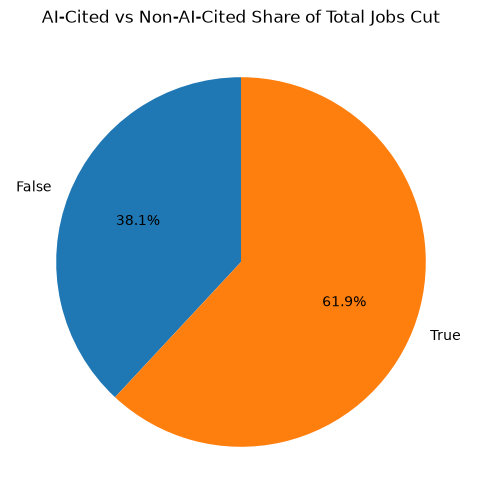

In [66]:
ai_contribution = df.groupby('ai_cited')['jobs_cut'].sum()

ai_contribution.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6),
    startangle = 90
)

plt.ylabel('')
plt.title('AI-Cited vs Non-AI-Cited Share of Total Jobs Cut')
plt.show()

**AI-cited layoffs accounted for 61.9% of total jobs cut, compared with 38.1% for non-AI-cited layoffs, indicating a larger share of job cuts was associated with AI-cited reasons.**

In [68]:
df.groupby('ai_cited')['stock_change_day_pct'].agg(['mean', 'median'])

,mean,median
ai_cited,,
False,-0.146154,-0.3
True,1.907143,1.9


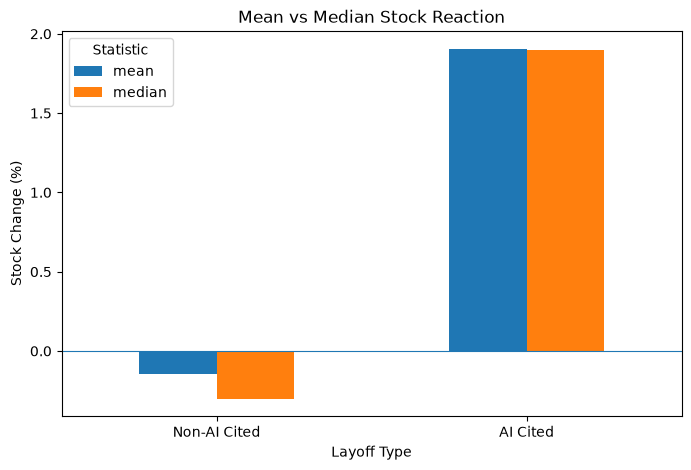

In [69]:
stock_stats = df.groupby('ai_cited')['stock_change_day_pct'].agg(
    mean='mean',
    median='median'
)

stock_stats.index = ['Non-AI Cited', 'AI Cited']

stock_stats.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.axhline(0, linewidth=0.8)
plt.xlabel('Layoff Type')
plt.ylabel('Stock Change (%)')
plt.title('Mean vs Median Stock Reaction')
plt.xticks(rotation=0)
plt.legend(title='Statistic')

plt.show()

**AI-cited layoffs were associated with a positive stock reaction, with both mean and median changes around +1.9%. In contrast, non-AI-cited layoffs showed a slight negative reaction, with a mean of -0.15% and median of -0.3%.**

In [92]:
ai_intensity = (
    df.groupby('sector')['ai_cited']
      .mean()
      .mul(100)
)

layoff_impact = (
    df.groupby('sector')['jobs_cut']
      .sum()
)

ai_investment = (
    df.groupby('sector')['simultaneous_ai_investment_bn']
      .mean()
)


from sklearn.preprocessing import MinMaxScaler

risk = pd.DataFrame({
    'AI_Layoff_Intensity': ai_intensity,
    'Layoff_Impact': layoff_impact,
    'AI_Investment': ai_investment
})

scaler = MinMaxScaler()

risk[['AI_Layoff_Intensity',
      'Layoff_Impact',
      'AI_Investment']] = scaler.fit_transform(
          risk[['AI_Layoff_Intensity',
                'Layoff_Impact',
                'AI_Investment']]
      ) * 100


risk['risk_score'] = (
    risk['AI_Layoff_Intensity'] * 0.4 +
    risk['Layoff_Impact'] * 0.35 +
    risk['AI_Investment'] * 0.25
).round(2)

risk = risk.sort_values('risk_score', ascending=False)

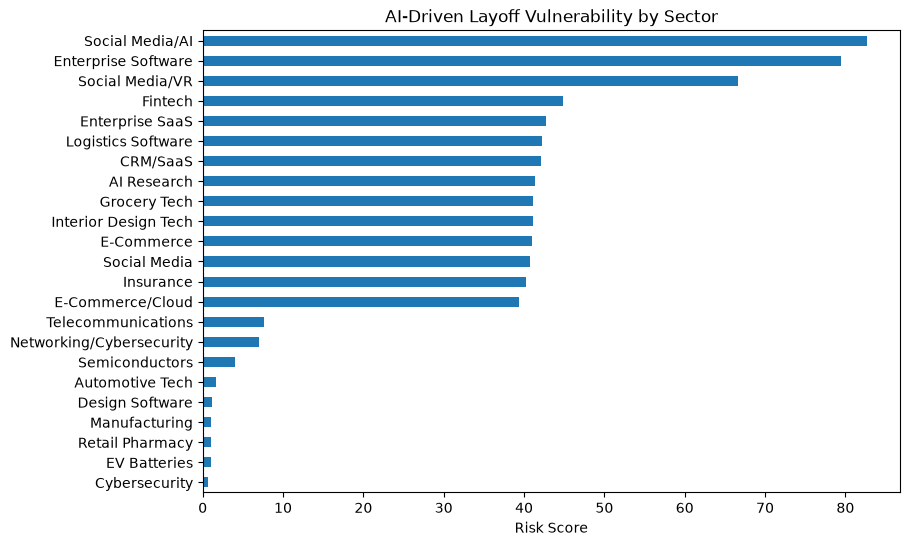

In [100]:
risk['risk_score'].plot(
    kind='barh',
    figsize=(9, 6)
)

plt.xlabel('Risk Score')
plt.ylabel('')
plt.title('AI-Driven Layoff Vulnerability by Sector')
ax = plt.gca()
ax.invert_yaxis()
plt.show()

**software-centric and digital media sectors face the highest risk of displacement, whereas hardware, cybersecurity, and physical manufacturing industries show strong resilience.**

**Jobs cut vs AI spend for each company simultaneously**

In [108]:
df[['company','jobs_cut','simultaneous_ai_investment_bn']].sort_values('jobs_cut')

,company,jobs_cut,simultaneous_ai_investment_bn
19,xAI,50,6.0
24,Ergo Insurance,200,0.2
15,T-Mobile,363,0.0
20,Palo Alto Networks,500,0.5
8,Pinterest,675,0.4
7,eBay,800,0.8
16,SK Battery America,958,0.0
5,Salesforce,1000,5.0
17,Walgreens,1000,0.0
25,Algoma Steel,1000,0.0
